In [128]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import ROOT

In [129]:
file = ROOT.TFile.Open("../DetectorSimulation/output/default.root")

In [130]:
hits = file.Get("hits")
hits.Print()

******************************************************************************
*Tree    :hits      : Energy deposit and position                            *
*Entries :   517687 : Total =        33219555 bytes  File  Size =   19702261 *
*        :          : Tree compression factor =   1.69                       *
******************************************************************************
*Br    0 :Energy    : Double_t hits                                          *
*Entries :   517687 : Total  Size=    6226526 bytes  File Size  =    4628515 *
*Baskets :      133 : Basket Size=      32000 bytes  Compression=   1.34     *
*............................................................................*
*Br    1 :PositionX : Double_t hits                                          *
*Entries :   517687 : Total  Size=    6226934 bytes  File Size  =    4649899 *
*Baskets :      133 : Basket Size=      32000 bytes  Compression=   1.34     *
*...................................................

In [131]:
tracks = file.Get("tracks")
tracks.BuildIndex("EventID")
tracks.Print()

******************************************************************************
*Tree    :tracks    : Track parameters                                       *
*Entries :   100000 : Total =        13237132 bytes  File  Size =    3735228 *
*        :          : Tree compression factor =   2.90                       *
******************************************************************************
*Br    0 :VertexPositionX : Double_t tracks                                  *
*Entries :   100000 : Total  Size=    1203826 bytes  File Size  =     121943 *
*Baskets :       30 : Basket Size=      32000 bytes  Compression=   9.86     *
*............................................................................*
*Br    1 :VertexPositionY : Double_t tracks                                  *
*Entries :   100000 : Total  Size=    1203826 bytes  File Size  =     121943 *
*Baskets :       30 : Basket Size=      32000 bytes  Compression=   9.86     *
*...................................................

In [132]:
num_hits = hits.GetEntries()

track_hits = {}

for i in range(num_hits):
    hits.GetEntry(i)
    eventID = hits.EventID
    if eventID not in track_hits:
        track_hits[eventID] = [[], [], []]
    track_hits[eventID][0].append(hits.PositionX)
    track_hits[eventID][1].append(hits.PositionY)
    track_hits[eventID][2].append(hits.PositionZ)

for eventID in track_hits:
    track_hits[eventID][0] = np.array(track_hits[eventID][0])
    track_hits[eventID][1] = np.array(track_hits[eventID][1])
    track_hits[eventID][2] = np.array(track_hits[eventID][2])

In [133]:
import random

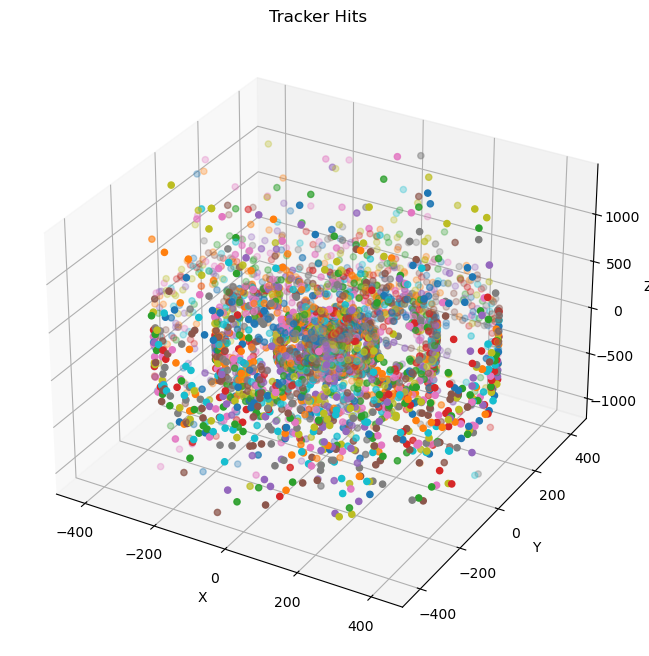

In [134]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Tracker Hits')

for track in track_hits.values():
    if random.random() < 0.01:
        x, y, z = track
        ax.scatter(x, y, z)

plt.show()

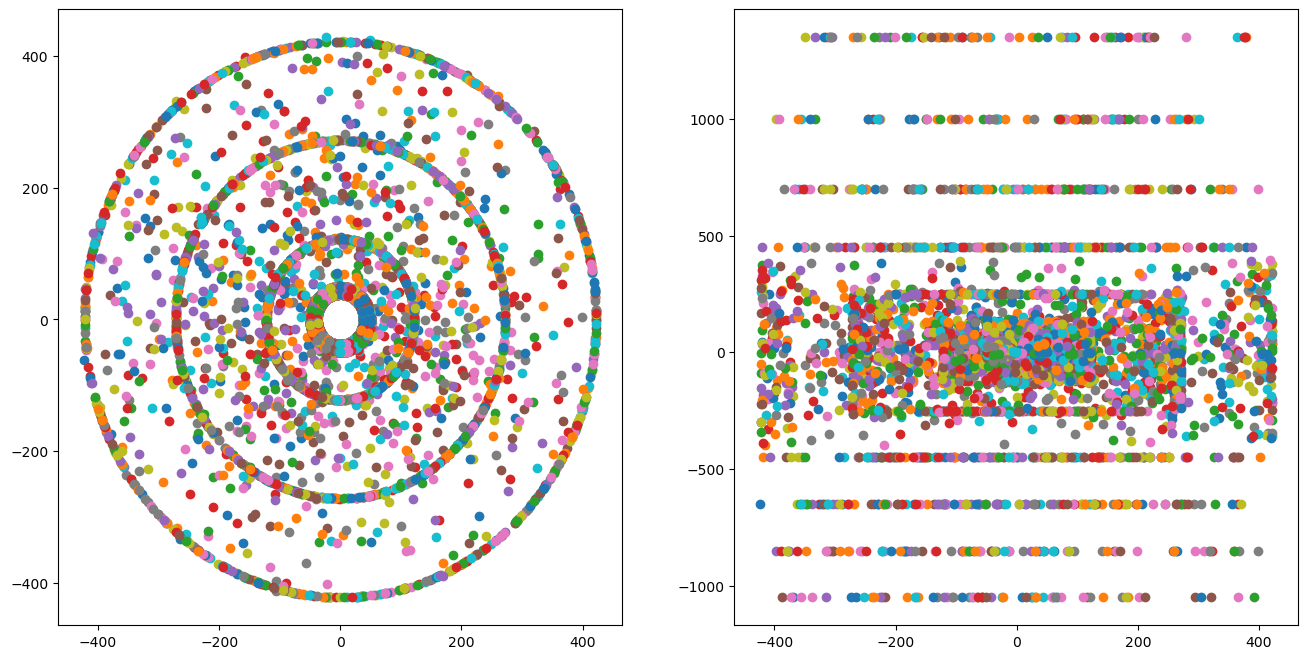

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for track in track_hits.values():
    if random.random() < 0.01:
        x, y, z = track
        axes[0].scatter(x, y)
        axes[1].scatter(x, z)

plt.show()

In [136]:
# for track in list(track_hits.values())[:100]:
#     x, y, z = zip(*track)
#     z = np.array(z)
#     z_scaled = (z - z[0]) / (z[-1] - z[0])
#     plt.plot(np.arange(len(z)), z)

# plt.show()

# First we cheat and skip the track finding step, and simply fit tracks

In [137]:
# num_hits_per_track = {}

# for eventID in track_hits:
#     num_hits_per_track[eventID] = len(track_hits[eventID])

# plt.hist(num_hits_per_track.values(), bins=max())
# plt.xlim(0, 20)

In [138]:
from helix_fitting import fit_helix, momentum_from_helix, DCA_from_helix, RMSE, helix

In [139]:
B = 1.7

cutoff_momentum = 50_000 # 50 MeV
cutoff_RMSE = 3

data = []

for eventID, track in track_hits.items():
    if len(track[0]) < 4:
        continue
    x, y, z = track
    x_c, y_c, R, tanl, z0, phi = fit_helix(x, y, z)

    fitted_pT, fitted_pZ = momentum_from_helix(R, tanl, B)
    fitted_p = np.sqrt(fitted_pT ** 2 + fitted_pZ ** 2)
    fitted_DCA = DCA_from_helix(x_c, y_c, R)

    tracks.GetEntryWithIndex(eventID)
    pX, pY, pZ = tracks.MomentumX, tracks.MomentumY, tracks.MomentumZ
    p = np.sqrt(pX ** 2 + pY ** 2 + pZ ** 2)
    pT = np.sqrt(pX ** 2 + pY ** 2)
    eta = np.arctanh(pZ / p)

    momentum_accuracy = np.abs(fitted_p - p) / p * 100
    transverse_momentum_accuracy = np.abs(fitted_pT - pT) / pT * 100
    z_momentum_accuracy = np.abs(fitted_pZ - pZ) / np.abs(pZ) * 100

    error = RMSE(x, y, z, x_c, y_c, z0, fitted_pZ, fitted_pT, R)

    if fitted_p > cutoff_momentum:
        continue

    data.append({
        "EventID": eventID,
        "Momentum (MeV/c)": round(p),
        "Transverse Momentum (MeV/c)": pT,
        "Z Momentum (MeV/c)": pZ,
        "Pseudorapidity": eta,
        "Momentum Accuracy (%)": momentum_accuracy,
        "Transverse Momentum Accuracy (%)": transverse_momentum_accuracy,
        "Z Momentum Accuracy (%)": z_momentum_accuracy,
        "DCA (mm)": fitted_DCA,
        "RMSE": error
    })

df = pd.DataFrame(data)
df.head()

,EventID,Momentum (MeV/c),Transverse Momentum (MeV/c),Z Momentum (MeV/c),Pseudorapidity,Momentum Accuracy (%),Transverse Momentum Accuracy (%),Z Momentum Accuracy (%),DCA (mm),RMSE
0,632,700,699.324386,30.747398,0.043953,0.319880,0.322406,200.977948,0.052198,0.018291
1,633,2000,1835.923621,-793.337544,-0.419689,0.323749,0.347568,200.196090,0.007194,0.010268
2,634,700,194.960790,-672.302231,-1.951447,0.755706,0.430691,200.782990,0.033023,0.123890
3,635,500,487.415367,-111.473138,-0.226754,0.209486,0.258188,200.717102,0.024048,0.017241
4,636,700,699.322923,-30.780676,-0.044001,0.022222,0.020288,198.974326,0.009012,0.023636


In [157]:
df.sort_values(by="Momentum (MeV/c)").head()

,EventID,Momentum (MeV/c),Transverse Momentum (MeV/c),Z Momentum (MeV/c),Pseudorapidity,Momentum Accuracy (%),Transverse Momentum Accuracy (%),Z Momentum Accuracy (%),DCA (mm),RMSE
90253,97733,100,47.003508,-88.264773,-1.387627,3.389887,1.840566,195.074469,0.135399,1.449903
76551,79640,100,99.945515,3.300599,0.033018,2.164062,2.111532,87.981243,1.352166,14.970311
83828,85849,100,24.615552,-96.923034,-2.079435,3.531836,4.885300,196.554813,2.864312,0.441185
8025,10813,100,91.636281,-40.034884,-0.424064,9.533717,4.532289,264.635616,1.367728,213.002947
25299,23372,100,89.106186,45.388188,0.489579,0.996271,6.368071,225.397172,5.794117,368.092374


In [140]:
def median_and_quantile_range(data, quantile_range):
    median = data.median()
    q_low = data.quantile(0.5 - quantile_range / 2)
    q_high = data.quantile(0.5 + quantile_range / 2)
    return median, q_low, q_high

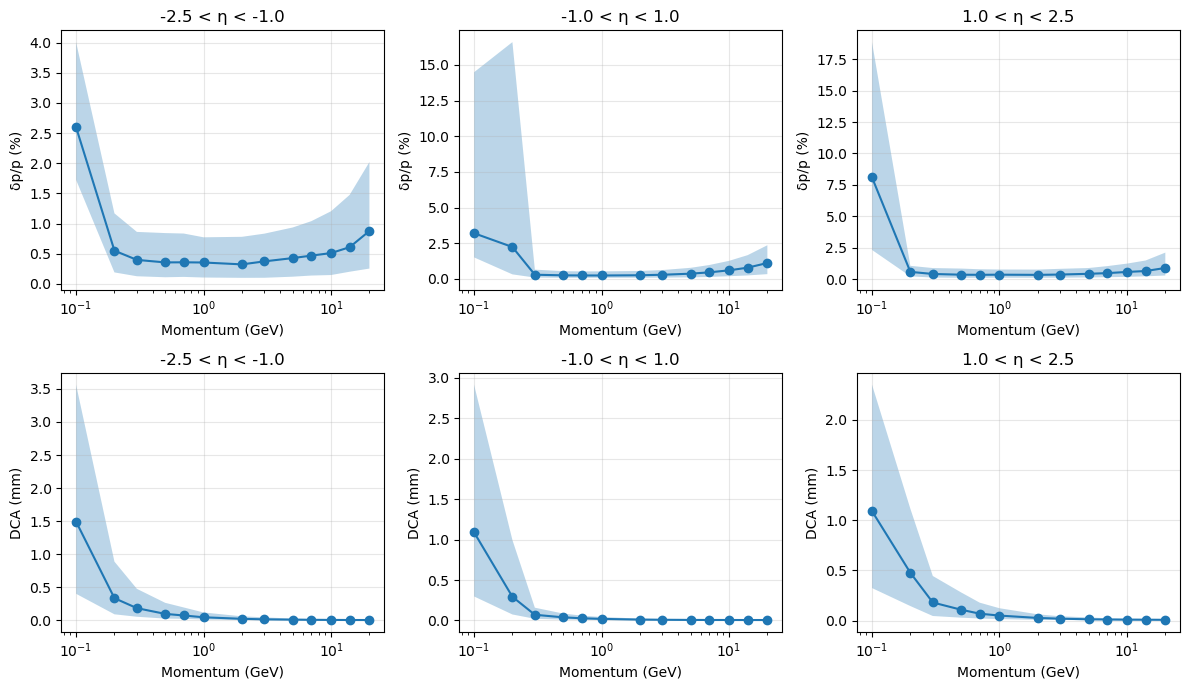

In [164]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                (df["Pseudorapidity"] < eta_hi)]
    
    momentum_points = sorted(df_eta["Momentum (MeV/c)"].unique())

    # axes[0, i].scatter(df_eta["Momentum (MeV/c)"], df_eta["Momentum Accuracy (%)"])
    # axes[1, i].scatter(df_eta["Momentum (MeV/c)"], df_eta["Momentum Accuracy (%)"])

    p_GeV = []

    p_accuracy_median = []
    p_accuracy_q16 = []
    p_accuracy_q84 = []
    DCA_median = []
    DCA_q16 = []
    DCA_q84 = []

    for p in momentum_points:
        subset = df_eta[df_eta["Momentum (MeV/c)"] == p]
        p_GeV.append(p / 1000)

        median, q16, q84 = median_and_quantile_range(subset["Momentum Accuracy (%)"], 0.68)
        p_accuracy_median.append(median)
        p_accuracy_q16.append(q16)
        p_accuracy_q84.append(q84)

        median, q16, q84 = median_and_quantile_range(subset["DCA (mm)"], 0.68)
        DCA_median.append(median)
        DCA_q16.append(q16)
        DCA_q84.append(q84)

    axes[0, i].plot(p_GeV, p_accuracy_median, marker="o")
    axes[0, i].fill_between(p_GeV, p_accuracy_q16, p_accuracy_q84, alpha=0.3)

    axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[0, i].set_xlabel("Momentum (GeV)")
    axes[0, i].set_ylabel("δp/p (%)")
    axes[0, i].grid(alpha=0.3)
    axes[0, i].set_xscale("log")

    axes[1, i].plot(p_GeV, DCA_median, marker="o")
    axes[1, i].fill_between(p_GeV, DCA_q16, DCA_q84, alpha=0.3)

    axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1, i].set_xlabel("Momentum (GeV)")
    axes[1, i].set_ylabel("DCA (mm)")
    axes[1, i].grid(alpha=0.3)
    axes[1, i].set_xscale("log")

plt.tight_layout()
plt.show()

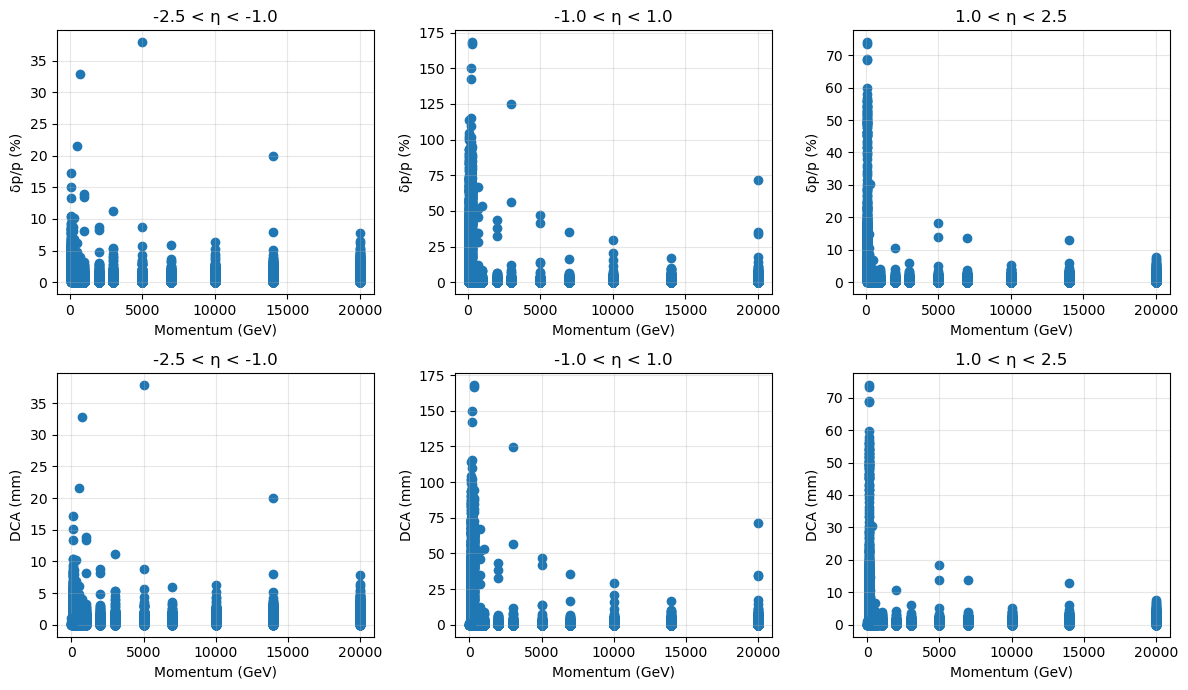

In [142]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                (df["Pseudorapidity"] < eta_hi)]
    
    momentum_points = sorted(df_eta["Momentum (MeV/c)"].unique())

    axes[0, i].scatter(df_eta["Momentum (MeV/c)"], df_eta["Momentum Accuracy (%)"])
    axes[1, i].scatter(df_eta["Momentum (MeV/c)"], df_eta["Momentum Accuracy (%)"])

    axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[0, i].set_xlabel("Momentum (GeV)")
    axes[0, i].set_ylabel("δp/p (%)")
    axes[0, i].grid(alpha=0.3)

    axes[1, i].plot(p_GeV, DCA_median, marker="o")
    axes[1, i].fill_between(p_GeV, DCA_q16, DCA_q84, alpha=0.3)

    axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1, i].set_xlabel("Momentum (GeV)")
    axes[1, i].set_ylabel("DCA (mm)")
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

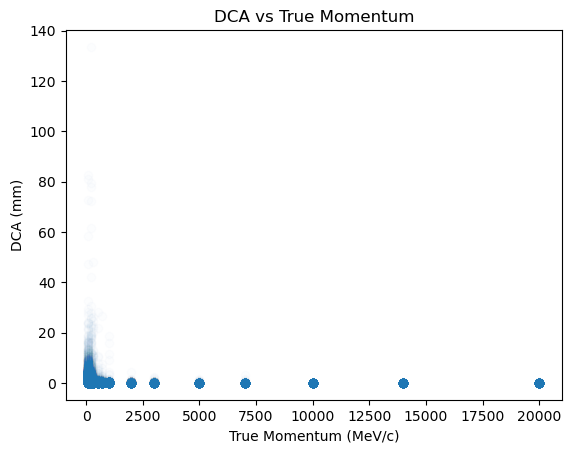

In [143]:
plt.scatter(df["Momentum (MeV/c)"], df["DCA (mm)"], alpha=0.01)
plt.xlabel("True Momentum (MeV/c)")
plt.ylabel("DCA (mm)")
plt.title("DCA vs True Momentum")
plt.show()

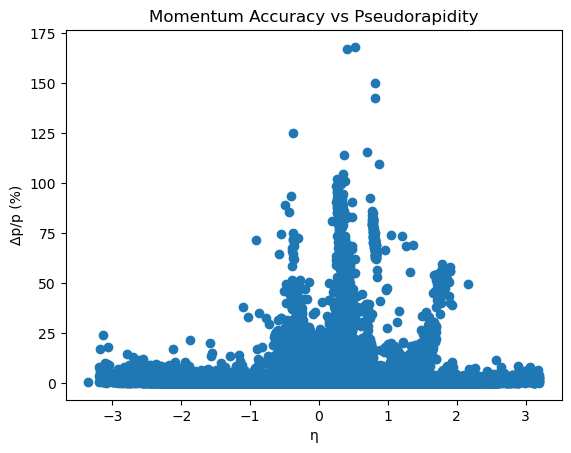

In [144]:
plt.scatter(df["Pseudorapidity"], df["Momentum Accuracy (%)"])
plt.xlabel("η")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs Pseudorapidity")
plt.show()

[]

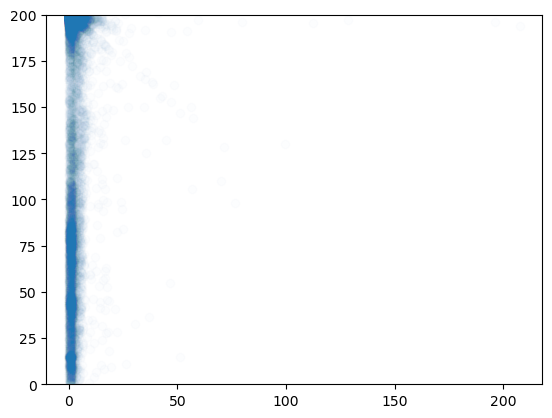

In [145]:
plt.scatter(df["Transverse Momentum Accuracy (%)"], df["Z Momentum Accuracy (%)"], alpha=0.01)
plt.ylim(0, 200)
plt.plot()

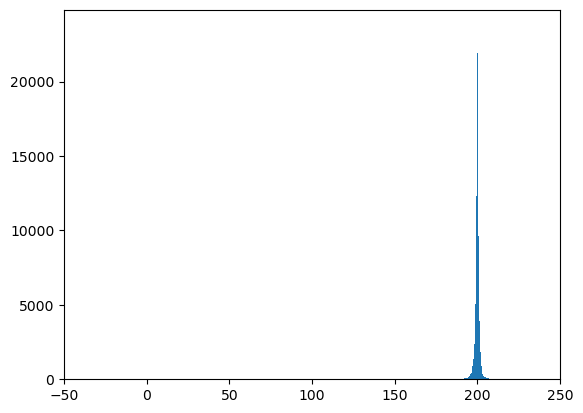

In [146]:
plt.hist(df["Z Momentum Accuracy (%)"], bins=np.arange(0, 300, 0.5))
plt.xlim(-50, 250)
plt.show()

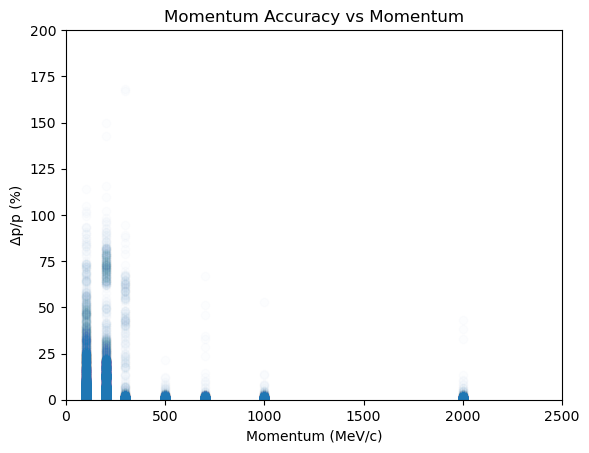

In [163]:
plt.scatter(df["Momentum (MeV/c)"], df["Momentum Accuracy (%)"], alpha=0.01)
plt.xlabel("Momentum (MeV/c)")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs Momentum")
plt.ylim(0, 200)
plt.xlim(0, 2500)
plt.show()

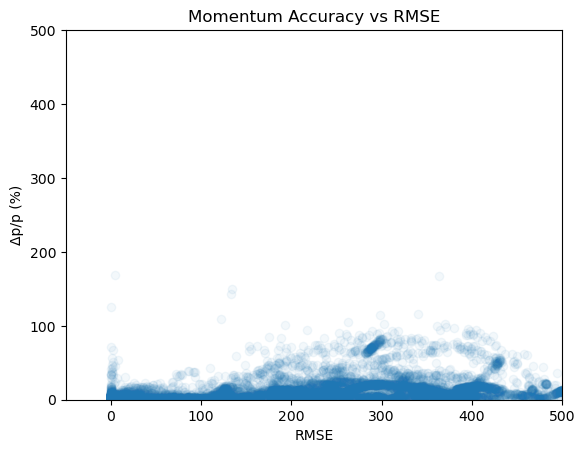

In [162]:
plt.scatter(df["RMSE"], df["Momentum Accuracy (%)"], alpha=0.05)
plt.xlabel("RMSE")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs RMSE")
plt.ylim(0, 500)
plt.xlim(-50, 500)
plt.show()

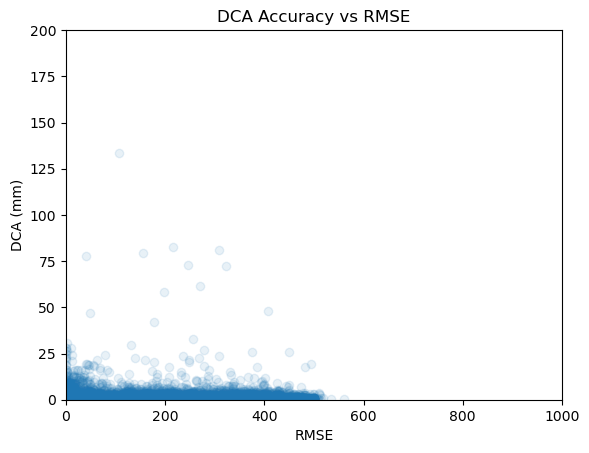

In [149]:
plt.scatter(df["RMSE"], df["DCA (mm)"], alpha=0.1)
plt.xlabel("RMSE")
plt.ylabel("DCA (mm)")
plt.title("DCA Accuracy vs RMSE")
plt.ylim(0, 200)
plt.xlim(0, 1000)
plt.show()

In [150]:
df.sort_values(by="Momentum Accuracy (%)", ascending=False).head(100)

,EventID,Momentum (MeV/c),Transverse Momentum (MeV/c),Z Momentum (MeV/c),Pseudorapidity,Momentum Accuracy (%),Transverse Momentum Accuracy (%),Z Momentum Accuracy (%),DCA (mm),RMSE
6366,7772,300,263.193249,143.976782,0.522884,168.249800,174.209922,347.293125,4.965976,4.959785
21193,22065,300,277.326219,114.412273,0.401667,167.018765,4.856052,561.076628,1.002765,363.980349
4769,2171,200,148.315764,134.173150,0.812316,149.992546,1.242075,255.439421,0.388970,134.526050
35779,37607,200,148.035045,134.482807,0.815136,142.439196,0.606404,243.121300,0.003215,132.589579
21264,23718,3000,2796.844180,-1085.201655,-0.378879,124.985290,125.167501,323.771232,0.466697,0.476424
...,...,...,...,...,...,...,...,...,...,...
50704,51895,200,191.157370,58.812071,0.303005,77.506481,1.185404,411.102276,0.339947,310.876063
67831,71144,200,191.096868,59.008365,0.304080,77.241775,0.082807,406.140799,0.497967,303.571921
27470,23966,200,191.461332,57.814864,0.297556,77.074254,1.660195,418.813490,0.359311,310.396899
6042,6176,200,191.091439,59.025944,0.304176,77.002882,0.542711,405.985503,0.255236,305.295192


In [151]:
df.sort_values(by="RMSE", ascending=False).head()

,EventID,Momentum (MeV/c),Transverse Momentum (MeV/c),Z Momentum (MeV/c),Pseudorapidity,Momentum Accuracy (%),Transverse Momentum Accuracy (%),Z Momentum Accuracy (%),DCA (mm),RMSE
12244,15197,200,175.117297,96.612278,0.526970,12.882136,0.636593,90.672085,0.357838,559.847910
48765,52185,200,176.230452,94.566525,0.513712,12.515795,0.734679,96.423749,0.142660,534.106990
13359,10408,200,175.196403,96.468753,0.526034,8.220717,1.265308,36.336960,0.954970,518.611425
42217,47422,200,176.053898,94.894811,0.515829,9.994516,0.925397,53.109259,0.691157,513.532964
88304,90314,200,170.167728,105.085415,0.583807,14.825031,0.096727,102.331042,0.058382,512.371266


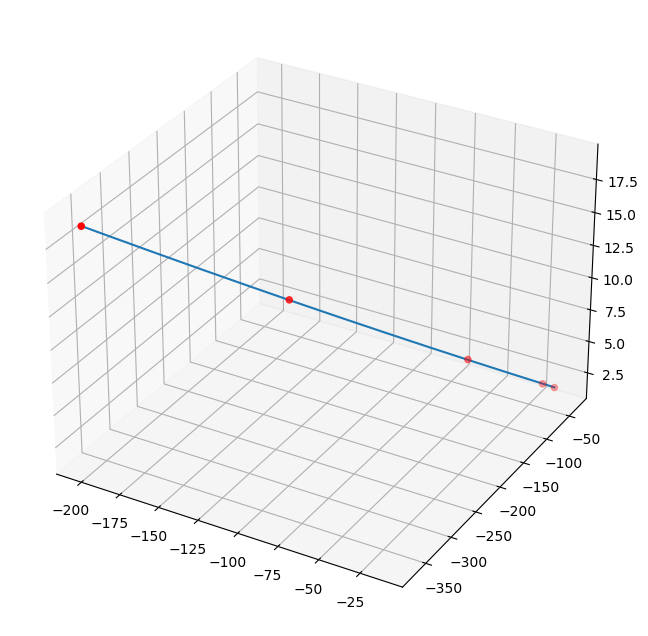

In [152]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

track = track_hits[632]
x, y, z = track

ax.scatter(x, y, z, c="r")

x_c, y_c, R, tanl, z0, phi = fit_helix(x, y, z)

fitted_pT, fitted_pZ = momentum_from_helix(R, tanl, B)
fitted_DCA = DCA_from_helix(x_c, y_c, R)

phi0 = phi[0]
sample_phi = np.linspace(phi[0], phi[-1], 1000)
x_fit, y_fit, z_fit = helix(x_c, y_c, z0, fitted_pZ, fitted_pT, R, sample_phi)
ax.plot(x_fit, y_fit, z_fit)

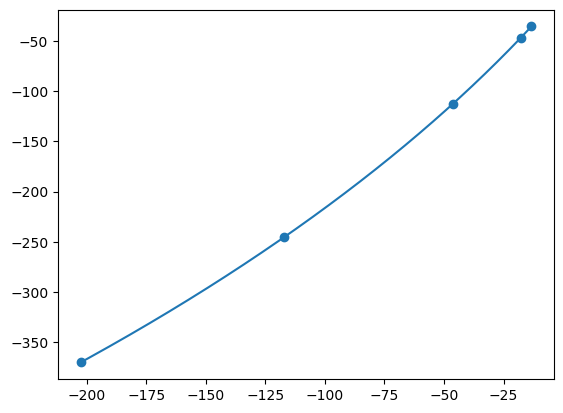

In [153]:
plt.scatter(x, y)
plt.plot(x_fit, y_fit)

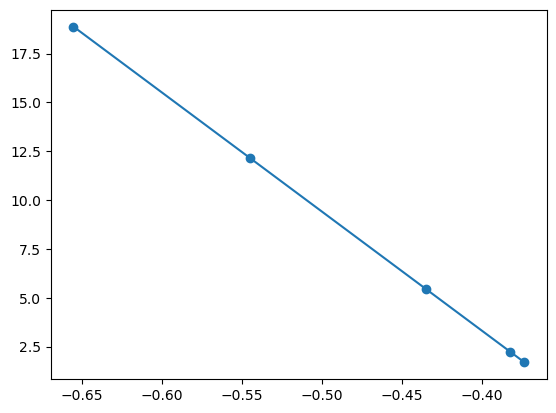

In [154]:
plt.scatter(phi, z)
plt.plot(sample_phi, z_fit)

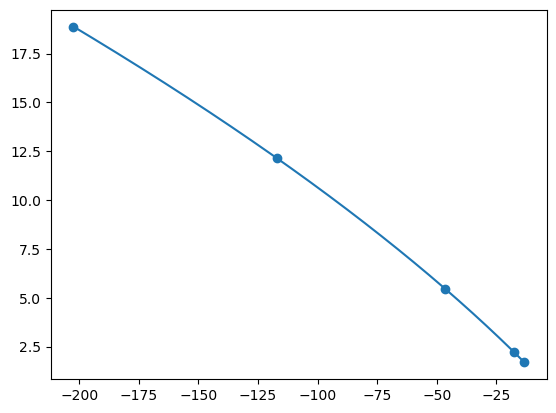

In [155]:
plt.scatter(x, z)
plt.plot(x_fit, z_fit)